# CHANCE-C Quickstarter Guide

Welcome to the **CHANCE-C** quickstart guide! 

This notebook will walk you through:
- Setting up and configuring CHANCE-C
- Understanding input data requirements
- Using the field mapping system for custom data
- Running your first simulation
- Visualizing and analyzing results

Let's get started!


## What is CHANCE-C?

CHANCE-C is a powerful agent-based modeling (ABM) framework designed for simulating urban housing markets, population dynamics, and weather risk interactions at the community scale.

### Key Features:
- **Agent-Based Modeling**: Simulates individual households and their housing decisions
- **Extreme Weather Risk Integration**: Models flood risk and weather adaptation behaviors
- **Flexible Data Input**: Supports custom data formats through field mapping
- **Spatial Analysis**: Works with geographic data (shapefiles, GeoJSON)
- **Policy Simulation**: Test interventions like zoning changes, flood insurance policies
- **Visualization Tools**: Built-in plotting and analysis capabilities

### Use Cases:
- Urban planning and policy analysis
- Extreme weather adaptation research
- Housing market dynamics studies


## Input Data and Default Files

CHANCE-C **includes example data files** that allow you to start using the package immediately without needing to prepare your own data first!

### Default Example Data

The package includes Baltimore-area example data files:
- **Geographic File**: Census block group boundaries (shapefile)
- **Population File**: 2018 population data by block group
- **Flood File**: FEMA 100-year flood zone data
- **Housing File**: 1993 housing characteristics and prices
- **Hedonic File**: Hedonic regression results for utility calculations

**You can run CHANCE-C immediately with these files - no data preparation needed!**

### Using Your Own Data

When you're ready to use your own data, CHANCE-C requires five types of input files:

1. **Geographic File** (`geo_filename`): Shapefile with census block groups
2. **Population File** (`pop_filename`): CSV with population data  
3. **Flood File** (`flood_filename`): CSV with flood risk data
4. **Housing File** (`housing_filename`): CSV with housing characteristics
5. **Hedonic File** (`hedonic_filename`): CSV with hedonic regression results

### Field Mapping System

CHANCE-C includes a flexible **field mapping system** that allows you to use data files with different column names. Instead of renaming your columns, you can create a mapping file that tells CHANCE-C how to interpret your data.

**For detailed information on field mapping, see**: [`chance_c/data/FIELD_MAPPING_README.md`](../chance_c/data/FIELD_MAPPING_README.md)


## Step 1: Import CHANCE-C

Let's start by importing the main Model class and other necessary modules:


In [1]:
import os

from chance_c import Model
from chance_c.data_loader import SimulationConfig


Pre-compiling numba functions for optimal performance...
Warming up numba functions...
Numba functions warmed up successfully!


## Step 2: Create Your First Model

The easiest way to get started is to create a Model with default settings. This will automatically use the included example data files.

### Option A: Use Default Configuration (Recommended for first-time users)

Create a model with all default settings - no file paths needed!


In [4]:
# Create a model with all default settings
# This automatically uses the included example data files
model = Model()

print("Model created successfully with default settings!")
print(f"Simulation: {model.config.simulation_name}")
print(f"Scenario: {model.config.scenario}")
print(f"Years: {model.config.start_year} to {model.config.start_year + model.config.n_years}")
print(f"Agent aggregation: {model.config.agent_housing_aggregation}")

# Show which data files are being used
print("\nUsing default data files:")
print(f"  Geographic: {os.path.basename(model.config.geo_filename)}")
print(f"  Population: {os.path.basename(model.config.pop_filename)}")
print(f"  Flood: {os.path.basename(model.config.flood_filename)}")
print(f"  Housing: {os.path.basename(model.config.housing_filename)}")
print(f"  Hedonic: {os.path.basename(model.config.hedonic_filename)}")

# Verify all files exist
all_files_exist = all([
    os.path.exists(model.config.geo_filename),
    os.path.exists(model.config.pop_filename),
    os.path.exists(model.config.flood_filename),
    os.path.exists(model.config.housing_filename),
    os.path.exists(model.config.hedonic_filename)
])
print(f"\nAll data files exist: {'✓' if all_files_exist else '✗'}")


Model created successfully with default settings!
Simulation: ABM_Baltimore_example
Scenario: Baseline
Years: 2018 to 2020
Agent aggregation: 10

Using default data files:
  Geographic: block_group_extract.shp
  Population: block_group_population_2018.csv
  Flood: block_group_percent_100yr_flood.csv
  Housing: block_group_housing_1993.csv
  Hedonic: simple_anova_hedonic_without_flood_bg0418.csv

All data files exist: ✓


### Option B: Create Model with Custom Settings

You can also create a model with custom parameters while still using the default data files:


In [5]:
# Example: Create model with custom parameters but default data files
custom_model = Model(
    simulation_name="My_Custom_Simulation",
    scenario="Custom_Scenario", 
    start_year=2020,
    n_years=3,
    agent_housing_aggregation=20  # Fewer agents for faster testing
)

print("Custom model created successfully!")
print(f"Simulation: {custom_model.config.simulation_name}")
print(f"Start year: {custom_model.config.start_year}")
print(f"Number of years: {custom_model.config.n_years}")
print(f"Still using default data files: ✓")

# Example: Create model with your own data files (uncomment to use)
# my_data_model = Model(
#     simulation_name="My_Data_Simulation",
#     geo_filename="path/to/your/geography.shp",
#     pop_filename="path/to/your/population.csv",
#     flood_filename="path/to/your/flood_data.csv", 
#     housing_filename="path/to/your/housing_data.csv",
#     hedonic_filename="path/to/your/hedonic_data.csv",
#     field_mapping_file="path/to/your/field_mapping.yml"  # Optional
# )

print("\nTip: Uncomment the code above to use your own data files!")


Custom model created successfully!
Simulation: My_Custom_Simulation
Start year: 2020
Number of years: 3
Still using default data files: ✓

Tip: Uncomment the code above to use your own data files!


## Step 3: Understand Required Data Fields

Let's explore what data fields are required for each input file type and what each field represents:


In [6]:
# Check required columns and their descriptions for each file type
file_types = ['geo', 'pop', 'flood', 'housing', 'hedonic']

for file_type in file_types:
    try:
        required_cols = model.config.get_required_columns(file_type)
        print(f"\n{file_type.upper()} FILE FIELDS:")
        print("-" * 50)
        for field, description in required_cols.items():
            print(f"  {field:20}: {description}")
    except Exception as e:
        print(f"Could not get requirements for {file_type}: {e}")

print("\n" + "=" * 60)
print("FIELD INFORMATION SUMMARY:")
print("=" * 60)
print("✓ The default data files already include all these required fields!")
print("✓ Field descriptions help you understand what data is needed")
print("✓ If your data has different column names, use the field mapping system")
print("✓ All fields are automatically loaded with correct datatypes")

print("\nFor field mapping help, see: chance_c/data/FIELD_MAPPING_README.md")



GEO FILE FIELDS:
--------------------------------------------------
  GISJOIN             : Unique identifier for each block group
  GEOID               : Unique identifier for each block group
  COUNTYFP            : County code
  TRACTCE             : Tract code
  BLKGRPCE            : Block group code
  ALAND               : Land area
  geometry            : Geometry of the block group

POP FILE FIELDS:
--------------------------------------------------
  GISJOIN             : Unique identifier for each block group
  AJWME001            : Population count (configurable field name)

FLOOD FILE FIELDS:
--------------------------------------------------
  GISJOIN             : Unique identifier for each flood zone
  Shape_Area          : Area of the flood zone
  fld_area            : Area of the flood zone
  perc_fld_area       : Percentage of the flood zone

HOUSING FILE FIELDS:
--------------------------------------------------
  GISJOIN             : Unique identifier for each bloc

## Step 4: Understanding Custom Data File Paths (Demonstration)

This step demonstrates how you would set up custom data file paths when using your own data. **This is for demonstration only** - we'll continue using the default model from Step 2 for the actual simulation.


In [7]:
# DEMONSTRATION: How to set up custom data file paths
# (This is just an example - we won't use these paths in this quickstart)

# Example data directory (this would be your actual data path)
example_data_directory = "/path/to/your/data"  

# Example file paths - these would be your actual data files
example_geo_filename = os.path.join(example_data_directory, "your_geography.shp")
example_pop_filename = os.path.join(example_data_directory, "your_population.csv")
example_flood_filename = os.path.join(example_data_directory, "your_flood_data.csv")
example_housing_filename = os.path.join(example_data_directory, "your_housing_data.csv")
example_hedonic_filename = os.path.join(example_data_directory, "your_hedonic_data.csv")

# This is how you would check if your files exist
example_files = {
    "Geographic": example_geo_filename,
    "Population": example_pop_filename,
    "Flood": example_flood_filename,
    "Housing": example_housing_filename,
    "Hedonic": example_hedonic_filename
}

print("DEMONSTRATION: Custom File Path Setup")
print("=" * 45)
print("This shows how you would set up paths to your own data files:")
print()
for file_type, filepath in example_files.items():
    print(f"{file_type:12}: {os.path.basename(filepath)}")

print(f"\nData directory: {example_data_directory}")
print("\nNote: These are example paths only!")
print("For this quickstart, we'll use the default model created in Step 2.")


DEMONSTRATION: Custom File Path Setup
This shows how you would set up paths to your own data files:

Geographic  : your_geography.shp
Population  : your_population.csv
Flood       : your_flood_data.csv
Housing     : your_housing_data.csv
Hedonic     : your_hedonic_data.csv

Data directory: /path/to/your/data

Note: These are example paths only!
For this quickstart, we'll use the default model created in Step 2.


## Step 5: Creating Models with Custom Data (Demonstration)

This step demonstrates how you would create a CHANCE-C model with your own data files. **This is for demonstration only** - we won't actually create this model since the files don't exist.


> *This code will not run since the files don’t exist – it’s just an example.*

```python
# When you have your own data files, you would create a model like this:
custom_model = Model(
    simulation_name="My_Custom_Simulation",
    scenario="Custom_Scenario",
    start_year=2020,
    n_years=5,
    geo_filename="/path/to/your/geography.shp",
    pop_filename="/path/to/your/population.csv",
    flood_filename="/path/to/your/flood_data.csv",
    housing_filename="/path/to/your/housing_data.csv",
    hedonic_filename="/path/to/your/hedonic_data.csv",
)
```

**Key points:**
- Specify all five required data files
- Optionally include a field mapping file
- Customize simulation parameters as needed
- Ensure all file paths are correct and files exist

**For this quickstart, we'll continue with the default model from Step 2.**


## Step 6: Run the Simulation

Now let's run a simulation using the default model we created in Step 2. This will use the included Baltimore example data:


In [3]:
# Spin up a model instance
model = Model(
    simulation_name="My_Custom_Simulation",
    scenario="Custom_Scenario", 
    sensitivity_run=True, # for a faster demonstration
)

# Run the simulation using the default model
model.run_simulation()

print("✓ Simulation completed successfully!")


2025-06-27 16:32:16,029 INFO: Setting up timestep information
2025-06-27 16:32:16,034 INFO: The first timestep is 2018-01-01 00:00:00
2025-06-27 16:32:16,040 INFO: The last timestep is 2020-01-01 00:00:00
2025-06-27 16:32:16,041 INFO: Setting up model landscape
2025-06-27 16:32:16,328 INFO: Numba-optimized distance patch took 0.161 seconds.
2025-06-27 16:32:16,395 INFO: 1220 block group nodes were added to the network
2025-06-27 16:32:16,396 INFO: Geographic data column types after processing:
2025-06-27 16:32:16,396 INFO:   GISJOIN: object
2025-06-27 16:32:16,396 INFO:   GEOID: object
2025-06-27 16:32:16,396 INFO:   COUNTYFP: object
2025-06-27 16:32:16,397 INFO:   TRACTCE: object
2025-06-27 16:32:16,397 INFO:   BLKGRPCE: object
2025-06-27 16:32:16,397 INFO:   ALAND: float64
2025-06-27 16:32:16,397 INFO:   geometry: geometry
2025-06-27 16:32:16,398 INFO: Population data column types after processing:
2025-06-27 16:32:16,398 INFO:   GISJOIN: object
2025-06-27 16:32:16,398 INFO:   AJWME0

✓ Simulation completed successfully!


## Step 7: Visualize Results

Now let's create some visualizations using the simulation results from our default model. CHANCE-C provides several built-in visualization methods:


1. Initial Population Distribution


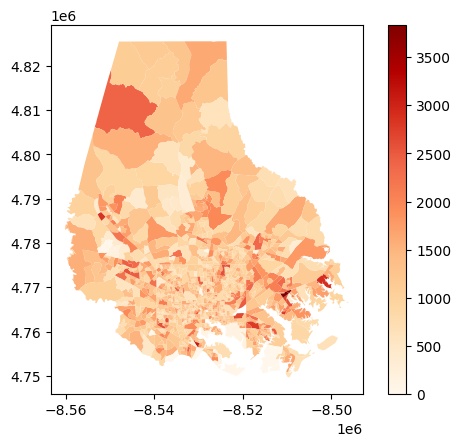

In [3]:
# Plot initial population distribution
print("1. Initial Population Distribution")
model.plot_initial_population()



2. Final Population Distribution


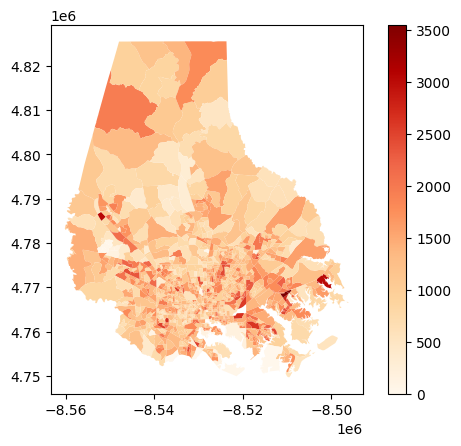

In [4]:
# Plot final population distribution  
print("\n2. Final Population Distribution")
model.plot_final_population()



3. Population Change Over Time


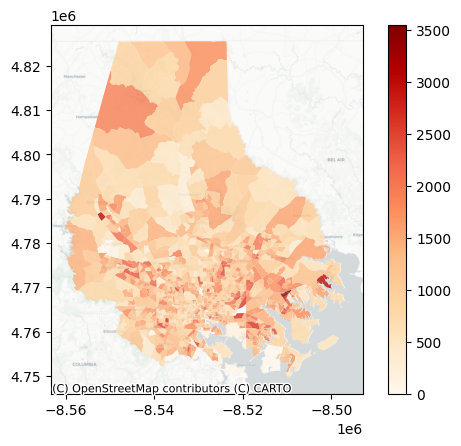

In [5]:
# Plot population change over time
print("\n3. Population Change Over Time")
model.plot_population_change()



4. Side-by-Side Population Comparison


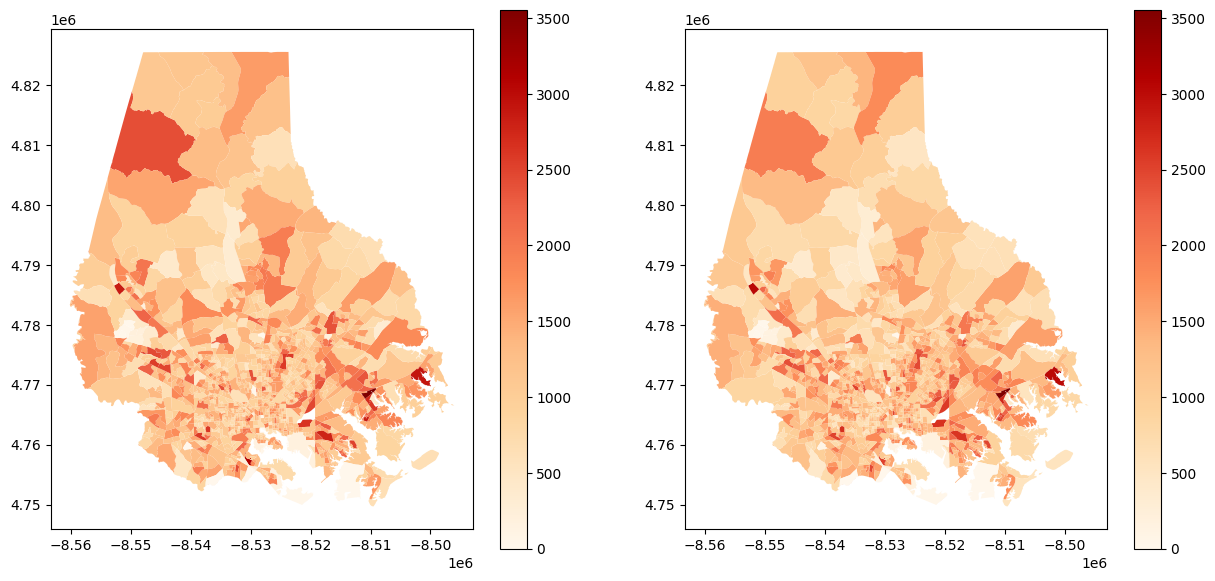

In [6]:
# Plot side-by-side comparison
print("\n4. Side-by-Side Population Comparison")
model.plot_population_side_by_side()


## Step 8: Analyze Results

Now let's analyze the results from our simulation using the default model. CHANCE-C provides several analysis capabilities:


In [7]:
# Get agent location history (example for agent ID 25000)
print("1. Agent Location History")
agent_history = model.get_agent_location_history(agent_id=25000)
if agent_history:
    print(f"   Agent 25000 location history: {agent_history}")
else:
    print("   No history found for agent 25000 (this is normal)")
    print("   Try different agent IDs or check model.simulator.network.agents.keys()")

# Combine housing dataframes for analysis
print("\n2. Combined Housing Data Analysis")
combined_df = model.combine_housing_dataframes()
print(f"   Combined data shape: {combined_df.shape}")

# Show some basic statistics
print("\n3. Simulation Results Summary")
if len(combined_df) > 0:
    print(f"   ✓ Total block groups: {len(combined_df)}")
    print(f"   ✓ Average population: {combined_df['population'].mean():.1f}")
    print(f"   ✓ Population std dev: {combined_df['population'].std():.1f}")
    print(f"   ✓ Average new price: ${combined_df['new_price'].mean():.0f}")
    print(f"   ✓ Price range: ${combined_df['new_price'].min():.0f} - ${combined_df['new_price'].max():.0f}")



1. Agent Location History
   Agent 25000 location history: ['240054114042', '240054114042', '240054114042']

2. Combined Housing Data Analysis
   Combined data shape: (2440, 13)

3. Simulation Results Summary
   ✓ Total block groups: 2440
   ✓ Average population: 1201.4
   ✓ Population std dev: 470.4
   ✓ Average new price: $92231
   ✓ Price range: $14000 - $370000


## Next Steps and Resources

Congratulations! You've completed the CHANCE-C quickstart guide. Here's what to do next:

### Immediate Next Steps:
1. **Get your data ready**: Prepare your geographic, population, flood, housing, and hedonic data files
2. **Set up field mapping**: If your column names differ from the required names, create a field mapping file
3. **Update file paths**: Modify the `data_directory` and file paths in this notebook to point to your data
4. **Run your first real simulation**: Execute the cells above with your actual data

### Learn More:
- **Field Mapping Guide**: [`chance_c/data/FIELD_MAPPING_README.md`](../chance_c/data/FIELD_MAPPING_README.md)
- **Example Configuration**: [`chance_c/data/example_config.yml`](../chance_c/data/example_config.yml)
- **Example Field Mapping**: [`chance_c/data/example_field_mapping.yml`](../chance_c/data/example_field_mapping.yml)

### Advanced Usage:
- Modify simulation parameters in your config file
- Create custom field mapping for your data
- Explore additional plotting and analysis methods
- Extend the model with custom engines or agents

### Tips for Success:
- Start with small datasets and short simulation periods for testing
- Use the field mapping system instead of renaming your data columns
- Check the console output for helpful error messages and debugging info
- Refer to the documentation and example files when in doubt

### Need Help?
- Check the error messages - they often contain helpful information
- Verify your data file formats and column names
- Ensure all required fields are present in your data
- Review the field mapping documentation for troubleshooting

Happy modeling with CHANCE-C!
